In [ ]:
 import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt


# 1- Armado de base SIG de referencias geograficas

In [ ]:
ruta_1= "/content/drive/MyDrive/MACRO DATA/GEOPANDAS/Bases/Provincia"

In [ ]:
ruta_2= "/content/drive/MyDrive/MACRO DATA/GEOPANDAS/Bases/departamento"

## a) Cargar Provincias

In [ ]:
provincias_gdf = gpd.read_file(ruta_1)
display(provincias_gdf.head())

In [ ]:
# Vemos las variables en la base
provincias_gdf.columns

In [ ]:
# Creamos un mapa para provincias_gdf
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
provincias_gdf.plot(ax=ax, cmap='viridis', edgecolor='black')

# Agregamos un título al mapa
ax.set_title('Mapa de Provincias de Argentina')

# Removemos las etiquetas de los ejes
ax.set_xticks([])
ax.set_yticks([])

# Mostramos el mapa
plt.show()

## b) Cargar Departamentos

Hacemos exactamente lo mismmo con los datos de los departamentos

In [ ]:
departamento_gdf = gpd.read_file(ruta_2)
display(departamento_gdf.head())

In [ ]:
departamento_gdf.columns

## c) Unir bases

En el estándar geoestadístico de Argentina, el código de los departamentos/partidos es una variable compuesta de 5 caracteres obligatorios (tipo String), estructurada de la siguiente manera:

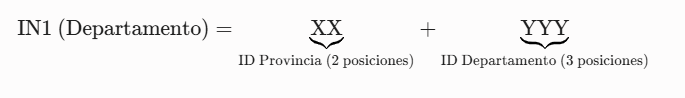

* **Capa de Provincias:** La variable IN1 contiene únicamente los 2 dígitos de la jurisdicción provincial (ej. 06 para Buenos Aires).

* **Capa de Departamentos:** La variable IN1 contiene los 5 dígitos completos (ej. 06077 para el Partido de Arrecifes).

Entonces en departamento_gdf creamos la variable "in1xx" que contien los dos primeros digitos de "in1" de dicha base. Esta nueva variable ahora nos permite unir los datos por departamento con los datos de las provincias.

In [ ]:
departamento_gdf['in1xx'] = departamento_gdf['in1'].str[:2]
display(departamento_gdf.head())

In [ ]:
departamento_con_provincias_gdf = departamento_gdf.merge(provincias_gdf, left_on='in1xx', right_on='in1', how= 'inner', suffixes=('_dep', '_prov'))
display(departamento_con_provincias_gdf.head())

###  Verificamos si hay valores faltantes

In [ ]:
missing_values_departamento_con_provincias_gdf = departamento_con_provincias_gdf.isnull().sum()
print("Valores faltantes por columna en departamento_con_provincias_gdf:")
display(missing_values_departamento_con_provincias_gdf)

In [ ]:
print(departamento_con_provincias_gdf.columns)

## d) Reordenando la base

Para la base final seleccionamos las variables que precisaremos para mapear (departamentos y provincias) e in1_dep que luego utilizaremos para unir con la base de ["Estimaciones Agricolas"](https://datosestimaciones.magyp.gob.ar/reportes.php?reporte=Estimaciones).

In [ ]:
departamento_con_provincias_gdf

### Nombres de las provincias

Vemos como aparece el nombre de las provincias en la base.

In [ ]:
unique_provinces = departamento_con_provincias_gdf['nam_prov'].unique()
print("Nombres únicos de provincias en la columna 'nam_prov'::")
for province in unique_provinces:
    print(f"- {province}")

El código anterior extrae y muestra todos los nombres de provincias únicos presentes en la columna `nam_prov` del GeoDataFrame `departamento_con_provincias_gdf`. Esto es útil para verificar los nombres exactos de las provincias y asegurar que el filtrado se realice correctamente.

### Contar la cantidad de Partidos/Comunas por Provincia

Este código agrupa el GeoDataFrame departamento_con_provincias_gdf por la columna nam_prov (nombre de la provincia). Para cada provincia, cuenta el número de valores únicos en la columna nam_dep (nombre del departamento). El resultado se almacena en un nuevo DataFrame llamado count_unique_gna_dep_per_prov, que tiene dos columnas: nam_prov y num_unique_gna_dep (que representa la cantidad de nombres de departamentos únicos para cada provincia).

In [ ]:
count_unique_gna_dep_per_prov = departamento_con_provincias_gdf.groupby('nam_prov')['nam_dep'].nunique().reset_index()
count_unique_gna_dep_per_prov.columns = ['nam_prov', 'num_unique_gna_dep']
display(count_unique_gna_dep_per_prov)

### Crear Zonas Geográficas

Vamos a categorizar las provincias en las zonas geográficas especificadas (NOA, NEA, Cuyo, Región Pampeana, Patagonia) y agregar esta información como una nueva columna en el GeoDataFrame `merged_gdf`.

In [ ]:
# Definir las provincias para cada zona geográfica
zones = {
    'NOA': ['Jujuy', 'Salta', 'Tucumán', 'Catamarca', 'Santiago del Estero', 'La Rioja'],
    'NEA': ['Formosa', 'Chaco', 'Corrientes', 'Misiones'],
    'Cuyo': ['San Juan', 'Mendoza', 'San Luis'],
    'Región Pampeana': ['Buenos Aires', 'Ciudad Autónoma de Buenos Aires', 'Santa Fe', 'Córdoba', 'Entre Ríos', 'La Pampa'],
    'Patagonia': ['Neuquén', 'Río Negro', 'Chubut', 'Santa Cruz', 'Tierra del Fuego, Antártida e Islas del Atlántico Sur']
}

# Crear una función para asignar la zona geográfica a cada provincia
def assign_zone(province_name):
    for zone, provinces in zones.items():
        if province_name in provinces:
            return zone
    return 'Otra'

# Aplicar la función para crear la nueva columna 'Zona_Geografica'
departamento_con_provincias_gdf ['Zona_Geografica'] = departamento_con_provincias_gdf ['nam_prov'].apply(assign_zone)

# Mostrar las primeras filas con la nueva columna y la cuenta de provincias por zona
display (departamento_con_provincias_gdf [['nam_prov', 'Zona_Geografica']].head())
display(departamento_con_provincias_gdf ['Zona_Geografica'].value_counts().reset_index())

In [ ]:
departamento_con_provincias_gdf["in1"]=departamento_con_provincias_gdf["in1_dep"]

Nos quedamos con las variables que necesitamos para seguir trabajando.

In [ ]:
departamento_con_provincias_gdf  = departamento_con_provincias_gdf[["nam_prov", "gna_dep", "nam_dep","geometry_prov", "geometry_dep", "in1", "Zona_Geografica"]]

In [ ]:
departamento_con_provincias_gdf

## e)  Guardar el GeoDataFrame en formato GeoPackage

 GeoPackage es un formato estándar abierto, basado en SQLite, que permite almacenar diferentes tipos de datos geoespaciales (vectores, rásteres, atributos) en un solo archivo. Esto facilita la portabilidad y el intercambio de datos entre diferentes sistemas de información geográfica (SIG) y aplicaciones. Además, puede manejar grandes volúmenes de datos de manera eficiente y es compatible con muchas plataformas.

In [ ]:
# Definimos la ruta donde vamos a guardar el archivo GeoPackage en Drive
output_gpkg_path = '/content/drive/MyDrive/MACRO DATA/GEOPANDAS/departamentos_con_provincias.gpkg'

# Antes de guardar nos aseguramos de que solo hay una columna de geometría activa
# En este caso, estableceremos 'geometry_dep' como la geometría principal y eliminaremos 'geometry_prov'.
df_to_save = departamento_con_provincias_gdf.set_geometry('geometry_dep')
df_to_save = df_to_save.drop(columns=['geometry_prov'])

# Guardamos el GeoDataFrame en formato GeoPackage
df_to_save.to_file(output_gpkg_path, driver='GPKG')

print(f"GeoDataFrame guardado exitosamente en: {output_gpkg_path}")

### Cargar el GeoDataFrame desde GeoPackage (ejemplo de uso)

In [ ]:
# Para cargar el GeoDataFrame en el futuro, simplemente usamos:
loaded_gdf = gpd.read_file(output_gpkg_path)
display(loaded_gdf.head())

# 2- Base de Estimaciones Agrícolas

Cargamos la base de estimaciones agrícolas

In [ ]:
ruta_3= "/content/drive/MyDrive/MACRO DATA/GEOPANDAS/Bases/Estimaciones.csv"

In [ ]:
Estimaciones = pd.read_csv(ruta_3, encoding='latin1', sep=';')
display(Estimaciones.head())

## Homogeneización de datos

Como vemos la variable "ID Departamento" tiene dos o tres digitos, esto se debe a que en el formato csv se ha eliminado el cero que se encuentra como primer digito. Lo mismo ocurre para la variable provincia. Entonces debemos crear nuevas variables que solucionen esto y por último concatenar ambas variables para reconstruir la variable "in1" de la base departamentos.

In [ ]:
# Homogeneizamos la variable 'ID Provincia' añadiendo un cero delante si es necesario
Estimaciones['ID Provincia'] = Estimaciones['ID Provincia'].astype(str).str.zfill(2)

# Mostramos las primeras filas para verificar el cambio
display(Estimaciones.head())

In [ ]:
# Homogeneizamos la variable 'ID Departamento' añadiendo ceros delante para asegurar 3 dígitos
Estimaciones['ID Departamento'] = Estimaciones['ID Departamento'].astype(str).str.zfill(3)

# Concatenamos 'ID Provincia' y 'ID Departamento' para crear la variable 'in1' unificada
Estimaciones['in1'] = Estimaciones['ID Provincia'].astype(str) + Estimaciones['ID Departamento'].astype(str)

# Mostramos las primeras filas para verificar los cambios, incluyendo la nueva columna 'in1'
display(Estimaciones.head())

#3- Unir base SIG y estimaciones

In [ ]:
departamento_con_provincias_gdf['in1'] = departamento_con_provincias_gdf['in1'].astype(str)
departamento_con_provincias_gdf = departamento_con_provincias_gdf.set_index('in1')

In [ ]:
print(f"Tipo de índice departamento_con_provincias_gdf: {departamento_con_provincias_gdf.index.dtype}")
print(f"Tipo de variable para 'in1' {Estimaciones['in1'].dtype}")

In [ ]:
base = departamento_con_provincias_gdf.merge(Estimaciones, left_index=True, right_on='in1', how='left')
display(base)

#4 Mapero de la soja por zona

#### Filtramos por camapaña y cultivo

In [ ]:
campana_filtro = '2024/25'
cultivo_filtro = 'Soja total'
df_camp_cultivo = base[(base['Campana'] == campana_filtro) & (base['Cultivo'] == cultivo_filtro)]
display(df_camp_cultivo .head())

### Mapeo de 'Sup. Sembrada (Ha)' por Departamento

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 20))

# Get the unique province names from the filtered data
relevant_provinces = df_camp_cultivo['nam_prov'].unique()

# Filter the base GeoDataFrame to only include departments from these relevant provinces
filtered_base_gdf = departamento_con_provincias_gdf[departamento_con_provincias_gdf['nam_prov'].isin(relevant_provinces)].copy()

# Plot the filtered base in grey for departments without data for the specific crop
filtered_base_gdf.set_geometry('geometry_dep').plot(ax=ax, color='#E0E0E0', edgecolor='white', linewidth=0.5)

# Set 'geometry_dep' as the active geometry for df_camp_cultivo before plotting
df_camp_cultivo = df_camp_cultivo.set_geometry('geometry_dep')

# Datos de la soja encima
df_camp_cultivo.plot(
    column='Sup. Sembrada (Ha)',
    cmap='viridis',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Superficie Sembrada (Ha)", 'orientation': "vertical"}
)

ax.set_title(f'Superficie sembrada de {cultivo_filtro} (Hectáreas) en Campaña {campana_filtro} por Departamento')
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Superficie Sembrada Promedio por Departamento

Este código calcula el promedio de la 'Sup. Sembrada (Ha)' para cada departamento, basándose en la campaña y el cultivo filtrados, y muestra los 10 departamentos con la mayor superficie semabrada (ha).

In [ ]:
average_performance_by_department = df_camp_cultivo.groupby('nam_dep')['Sup. Sembrada (Ha)'].mean().reset_index()
average_performance_by_department = average_performance_by_department.sort_values(by='Sup. Sembrada (Ha)', ascending=False)

display(average_performance_by_department.head(10))

El departamento de Río Cuarto (Córdoba) muestra el promedio más alto de Superficie Sembrada en hectáreas, seguido por General López (Sta Fe) y Marcos Juárez (Córdoba) .

## Superficie sembrada por provincia

El siguiente gráfico de barras muestra la superficie sembrada total (en hectáreas) para cada provincia, lo que permite una comparación directa de la producción agrícola a nivel provincial.

In [ ]:
total_seeded_area_by_province = df_camp_cultivo.groupby('nam_prov')['Sup. Sembrada (Ha)'].sum().reset_index()
total_seeded_area_by_province = total_seeded_area_by_province.sort_values(by='Sup. Sembrada (Ha)', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x='Sup. Sembrada (Ha)', y='nam_prov', hue='nam_prov', data=total_seeded_area_by_province, palette='viridis', ax=ax, legend=False)
ax.set_title(f'Superficie Sembrada de {cultivo_filtro} por Provincia en Campaña {campana_filtro}')
ax.set_xlabel('Superficie Sembrada Total (Ha)')
ax.set_ylabel('Provincia')
plt.tight_layout()
plt.show()

In [ ]:
total_seeded_area_by_province

## Comparación de Producción Total por Provincia

In [ ]:
# Sumar la producción real (en Toneladas) solo para Soja 24/25
total_production_by_province = df_camp_cultivo.groupby('nam_prov')['Producción (Tn)'].sum().reset_index()
total_production_by_province = total_production_by_province.sort_values(by='Producción (Tn)', ascending=False)
display(total_production_by_province.head())



#5-  Correlación entre Producción y Superficie Sembrada

In [ ]:
correlation_df = df_camp_cultivo[['Sup. Sembrada (Ha)', 'Producción (Tn)', 'nam_prov']].dropna()

# Calculamos el coeficiente de correlación de Pearson.
correlation = correlation_df['Sup. Sembrada (Ha)'].corr(correlation_df['Producción (Tn)'])
print(f"La correlación entre Superficie Sembrada (ha) y Producción (t) es: {correlation:.2f}")

Vemos una **alta correlación lineal positiva** entre las Superficie Sembrada (ha) y la Producción (t) **(0.96)**.

In [ ]:
print('Variables correlacionadas:', correlation_df.columns)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(x='Sup. Sembrada (Ha)', y='Producción (Tn)', data=correlation_df, ax=ax, hue='nam_prov', legend='full', palette='viridis')
ax.set_title(f'Correlación entre Superficie Sembrada y Producción de {cultivo_filtro} en Campaña {campana_filtro}')
ax.set_xlabel('Superficie Sembrada (ha)')
ax.set_ylabel('Producción (t)')
plt.tight_layout()
plt.show()

Cada punto en el gráfico representa un departamento, y el color indica la provincia a la que pertenece. Esto nos permite ver la correlación a nivel departamental, agrupada por provincia.

El diagrama de dispersión y el coeficiente de correlación indican la relación entre la superficie cultivada y la producción. Una correlación positiva sugiere que, a medida que aumenta la superficie cultivada, la producción tiende a incrementarse también, lo cual es previsible en la producción agrícola.

# 6- Medición del Rendimiento en el Cultivo de Soja

Para medir el rendimiento de la soja (o cualquier cultivo), el dato técnico y agronómico estándar es la **cantidad de toneladas sobre la superficie cosechada**.

Sin embargo, en la gestión agrícola se distinguen claramente dos métricas según el objetivo del análisis (productivo vs. económico/financiero):

---

### 1. Rendimiento sobre Superficie Cosechada (Enfoque Agronómico)
Es el cálculo estándar utilizado en informes técnicos y estadísticas sectoriales (Bolsa de Cereales, INTA, etc.). Mide la **productividad real de la tierra que efectivamente completó el ciclo**.

$$Rendimiento = \frac{\text{Toneladas Totales Obtenidas}}{\text{Superficie Cosechada (ha)}}$$

* **Aplicación:** Permite aislar y evaluar el potencial biológico del cultivo, la respuesta al paquete tecnológico y el manejo agronómico del lote.
* **Ejemplo:** Si un evento climático destruye una fracción del lote, esta métrica refleja la productividad de lo que quedó en pie, sin distorsionar la eficiencia del manejo técnico.

### 2. Rendimiento sobre Superficie Sembrada (Enfoque Económico y de Riesgo)
Este cálculo actúa como una métrica de gestión financiera. Al dividir la producción total por las hectáreas sembradas originalmente, se internaliza el impacto de la **superficie perdida** (la brecha entre siembra y cosecha).

$$Rendimiento_{\text{efectivo}} = \frac{\text{Toneladas Totales Obtenidas}}{\text{Superficie Sembrada (ha)}}$$

* **Aplicación:** Es crucial para la auditoría de costos y el análisis de rentabilidad. Los costos hundidos en insumos (semillas, fertilizantes, preemergentes) y labores se ejecutan sobre la superficie sembrada. Si hay una pérdida de área, esta métrica expone el impacto financiero real del riesgo climático sobre la inversión inicial.

## a) Rendimiento sobre Superficie Cosechada (Enfoque Agronómico)

In [ ]:
# Rendimiento real (Tn/Ha)
df_camp_cultivo['Rendimiento_Calculado'] = df_camp_cultivo['Producción (Tn)'] / df_camp_cultivo['Sup. Cosechada (Ha)']
average_perf = df_camp_cultivo.groupby('nam_dep')['Rendimiento_Calculado'].mean().reset_index()
average_perf = average_perf.sort_values(by='Rendimiento_Calculado', ascending=False).round(2)
display(average_perf.head())

### Visualización del Rendimiento Promedio por Departamento

Este mapa muestra el 'Rendimiento Promedio (Tn/Ha)' por departamento, lo que permite una visualización clara de las diferencias de rendimiento en cada región para el cultivo y la campaña seleccionados.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 20))

# Obtenemos los nombres únicos de las provincias a partir de los datos filtrados.
relevant_provinces = df_camp_cultivo['nam_prov'].unique()

# Filtramos el GeoDataFrame base para incluir solo los departamentos de estas provincias relevantes.
filtered_base_gdf = departamento_con_provincias_gdf[departamento_con_provincias_gdf['nam_prov'].isin(relevant_provinces)].copy()

# Plot the filtered base in grey for departments without data for the specific crop
filtered_base_gdf.set_geometry('geometry_dep').plot(ax=ax, color='#E0E0E0', edgecolor='white', linewidth=0.5)

# Set 'geometry_dep' as the active geometry for df_camp_cultivo before plotting
df_camp_cultivo = df_camp_cultivo.set_geometry('geometry_dep')

# Datos de la soja encima
df_camp_cultivo.plot(
    column='Rendimiento_Calculado',
    cmap='viridis',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Rendimiento (t/ha)", 'orientation': "vertical"}
)

ax.set_title(f'Rendimiento de {cultivo_filtro} (Toneladas / Superficie Cosechada (ha)) en Campaña {campana_filtro} por Departamento')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## b) Rendimiento sobre Superficie Sembrada (Enfoque Económico y de Riesgo)

In [ ]:
# Rendimiento real (Tn/Ha)
df_camp_cultivo['Rendimiento_Calculado_2'] = df_camp_cultivo['Producción (Tn)'] / df_camp_cultivo['Sup. Sembrada (Ha)']
average_perf = df_camp_cultivo.groupby('nam_dep')['Rendimiento_Calculado_2'].mean().reset_index()
average_perf = average_perf.sort_values(by='Rendimiento_Calculado_2', ascending=False).round(2)
display(average_perf.head())

### Visualización del Rendimiento Promedio por Departamento

Este mapa muestra el 'Rendimiento Promedio (Tn/Ha)' por departamento, lo que permite una visualización clara de las diferencias de rendimiento en cada región para el cultivo y la campaña seleccionados.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 20))

# Obtenemos los nombres únicos de las provincias a partir de los datos filtrados.
relevant_provinces = df_camp_cultivo['nam_prov'].unique()

# Filtramos el GeoDataFrame base para incluir solo los departamentos de estas provincias relevantes.
filtered_base_gdf = departamento_con_provincias_gdf[departamento_con_provincias_gdf['nam_prov'].isin(relevant_provinces)].copy()

# Representamos gráficamente la base filtrada en gris para los departamentos sin datos para el cultivo específico.
filtered_base_gdf.set_geometry('geometry_dep').plot(ax=ax, color='#E0E0E0', edgecolor='white', linewidth=0.5)

#Establecemos'geometry_dep' como la geometría activa para df_camp_cultivo antes de graficar.
df_camp_cultivo = df_camp_cultivo.set_geometry('geometry_dep')

# principales caracteristicas del plot
df_camp_cultivo.plot(
    column='Rendimiento_Calculado_2',
    cmap='viridis',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Rendimiento (t/ha)", 'orientation': "vertical"}
)

ax.set_title(f'Rendimiento de {cultivo_filtro} (Toneladas / Superficie Sembrada (ha)) en Campaña {campana_filtro} por Departamento')
ax.set_axis_off()
plt.tight_layout()
plt.show()

##c) Superficie Perdida: Diferencia entre Superficie Sembrada y Cosechada

In [ ]:
# Calculamos la diferencia entre la superficie sembrada y la cosechada
df_camp_cultivo['Superficie_Perdida_Ha'] = df_camp_cultivo['Sup. Sembrada (Ha)'] - df_camp_cultivo['Sup. Cosechada (Ha)']

# Filtramos para mostrar solo donde hay una diferencia (superficie perdida > 0)
diferencias_superficie = df_camp_cultivo[df_camp_cultivo['Superficie_Perdida_Ha'] > 0].copy()

# Ordenamos por la mayor superficie perdida
diferencias_superficie = diferencias_superficie.sort_values(by='Superficie_Perdida_Ha', ascending=False)

display(diferencias_superficie[['nam_prov', 'nam_dep', 'Sup. Sembrada (Ha)', 'Sup. Cosechada (Ha)', 'Superficie_Perdida_Ha']].head(10))

print(f"\nTotal de departamentos con superficie perdida: {len(diferencias_superficie)}")

total_sembrada = df_camp_cultivo['Sup. Sembrada (Ha)'].sum()
total_cosechada = df_camp_cultivo['Sup. Cosechada (Ha)'].sum()

print(f"Total de superficie sembrada: {total_sembrada:,.0f} Ha")
print(f"Total de superficie cosechada: {total_cosechada:,.0f} Ha")
print(f"Total de superficie perdida: {df_camp_cultivo['Superficie_Perdida_Ha'].sum():,.0f} Ha")

if total_sembrada > 0:
    ratio = total_cosechada / total_sembrada
    print(f"Ratio de Superficie Cosechada / Superficie Sembrada: {ratio:.2f}")
else:
    print("No hay superficie sembrada para calcular el ratio.")

### c.1) Visualización de Departamentos con Superficie Perdida

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 20))

# Nombres de las provincias
relevant_provinces = df_camp_cultivo['nam_prov'].unique()

# Filtramos el GeoDataFrame base para incluir solo los departamentos de estas provincias relevantes.
filtered_base_gdf = departamento_con_provincias_gdf[departamento_con_provincias_gdf['nam_prov'].isin(relevant_provinces)].copy()

# Represente gráficamente la base filtrada en gris para los departamentos sin datos para el cultivo específico.
filtered_base_gdf.set_geometry('geometry_dep').plot(ax=ax, color='#E0E0E0', edgecolor='white', linewidth=0.5)

# Nos aseguramos que df_camp_cultivo tenga 'geometry_dep' como geometría activa (esto ya se hizo en gráficos anteriores, pero es bueno asegurarse).
df_camp_cultivo = df_camp_cultivo.set_geometry('geometry_dep')

# Graficar únicamente los departamentos con área perdida
plot_df = df_camp_cultivo[df_camp_cultivo['Superficie_Perdida_Ha'] > 0]
plot_df.plot(
    column='Superficie_Perdida_Ha',
    cmap='YlOrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Superficie Perdida (Ha)", 'orientation': "vertical"}
)

# Agregamos los nombres de los departamentos como etiquetas para los departamentos con área perdida.
for idx, row in plot_df.iterrows():
    if row['geometry_dep'] is not None and not row['geometry_dep'].is_empty:
        try:
            centroid = row['geometry_dep'].centroid
            ax.annotate(text=row['nam_dep'], xy=(centroid.x, centroid.y),
                        xytext=(3, 3), textcoords="offset points",
                        color='black', fontsize=8, ha='center')
        except Exception as e:
            print(f"Could not calculate centroid or annotate for department {row['nam_dep']}: {e}")

ax.set_title(f'Superficie Perdida de {cultivo_filtro} (Ha) en Campaña {campana_filtro} por Departamento')
ax.set_axis_off()
plt.tight_layout()
plt.show()

 Se identificaron **145 departamentos con diferencias entre la superficie sembrada y la cosechada**. En total, se sembraron 17,971,465 Ha, se cosecharon 17,432,716 Ha, resultando en una pérdida de 538,749 Ha. El ratio de Superficie Cosechada sobre Superficie Sembrada es de 0.97, lo que indica que **aproximadamente el 97% de la superficie sembrada fue cosechada**.

### c.2) Superficie Perdida Total por Provincia

In [ ]:
lost_area_by_province = df_camp_cultivo.groupby('nam_prov')['Superficie_Perdida_Ha'].sum().reset_index()
lost_area_by_province = lost_area_by_province.sort_values(by='Superficie_Perdida_Ha', ascending=False)
print("Superficie Perdida Total por Provincia (Ha):")
display(lost_area_by_province)